# Gear 2.2 dummy replay

Трек **2** (исторический симулятор). Тонкий драйвер поверх `research.gear22_backtest`.
Правила — в `policy.py`, прогон — в `replay.py`. Этот ноутбук их не переписывает.

**Не PnL-ready.** `potential_pp` — наблюдение, не claim прибыли. Open-at-end не `ClosedTrade`, но попадает в `result.to_trades_frame()` как unclosed-строка (`status="open"`, `ts_close` пустой).
**Trade_Lat не моделируется** (fill = 1 Hz `spread_last` той секунды).

**Кандидат наблюдения, не оптимум.** Ячейка 2 берёт `DEFAULT_OBSERVE_PARAMS` из `params_frozen.py`. Это точка на гребне (`p50_open ≥ 0.60`, `min_profit_pp ∈ [0.15, 0.25]`), **не** плато 20–30% по всем осям, **не** PnL-claim, **не** live-ready. Close-гейт = цена той же секунды, что fill.


## Допущения прогона

- **clock** = `ts_s`. `replay_frame` всегда сортирует `(ts_s, coin)` (time-major; на одной секунде — лексикографический `coin`).
- **fill** = `spread_last` открытой стороны на секунде open.
- **close** = `potential_pp = fill_spread_pp + spread_last_opposite - fee_round_trip_pp`.
- **K=1 до гира 2.5** = одна позиция на всех монетах, сделки только последовательно. Один `replay_hive` / `replay_frame` по полной таблице, `SLOT_MODE="global"` (default). Не крутить `for coin in COINS: replay(...)` — каждый вызов сбрасывает слот.
- В позиции close смотрит **только ряд held-coin** на этой секунде; если монеты нет — hold. Открытая на конце скана позиция — `result.open_positions`, не `ClosedTrade`. Та же строка есть в `df_trades = result.to_trades_frame()`: `status="open"`, `reason_close="unclosed"`, `ts_close` NaN, `exit_spread_pp` / `potential_pp` — last seen (если есть).
- `COINS`: `None` (все монеты) или `["KAITO"]`. **Не** пишите `COINS = "KAITO"` — голая строка раньше итерировалась как символы K,A,I,T,O. Replay теперь трактует `str` как одну монету, но в ноутбуке держите список.
- `SLOT_MODE="per_coin"` — явный opt-in, research / около 2.5; **не** живой контур.
- NaN / not usable → hold. Missing ≠ close.
- **`min_theta_close=0` — включённый гейт, а не выключенный.** Проверка идёт через `threshold is None` (`policy._enabled_gt`), поэтому `0` требует `theta_1m` close-стороны строго `> 0` и делает гейт fail-closed по NaN. Выключает гейт только `None`.
- **`closed` усечён снизу по построению.** Close-гейт и exit-цена берутся из одной строки, принудительного выхода нет, поэтому у каждой закрытой сделки `potential_pp >= min_profit_pp` тождественно, а убыточные удержания остаются в `open_positions`. `sum` / `mean` по `closed` нельзя читать как результат; смотрите `duty_cycle` и `close_gate_silent_s`.
- **`EVENT_DATES=None` шире контрактного span.** На диске 35 партиций `2026-08-10 … 09-13`, а объявленный span таблицы фич — `2026-08-10T00:00Z → 2026-08-27T12:00Z` (`docs/gear22-backtest-features.md`). Окно отбора canary-30 кончается `2026-08-27T11:40Z`, то есть около половины прогона in-sample по отбору вселенной.

Открывать из корня репо:

```
PYTHONPATH=. jupyter notebook research/gear22_backtest/replay.ipynb
```


# Гир 2.2: кандидат ручек после свипа

**Трек:** 2 — историческая модель. **Гир:** 2.2 (наблюдение).  
**Статус:** кандидат ручек зафиксирован в `research/gear22_backtest/params_frozen.py` как `FROZEN` = `DEFAULT_OBSERVE_PARAMS`. Это не плато 20–30% по всем осям, не оценка прибыли и не готовность к живой торговле.

Не гир 2.5 (политика размера) и не гир 3 (поиск по каталогу эпизодов). Живого профиля 2.2 в `app/bot/**` нет. Отправки заявок нет.

## Вердикт

Дешёвая сетка вокруг старых ручек ноутбука не дала плато: **0 из 192** ячеек. Расширение к более строгим порогам открытия нашло **гребень**, не плоскую внутренность. Зафиксирован консервативный кандидат на этом гребне.

`combined_mark` — расчётная **метка наблюдения** (сумма закрытых `potential_pp` плюс оценка ещё открытой позиции), не прибыль.

## Лестница гиров

С номером гира растут охват, адаптивность, риск подгонки и операционная сложность. Гир 2.2 стоит **после** закрытого контура гира 2: тот же мультимонетный прогон, но строже статистика (занятость слота, усечение выборки, локальная устойчивость ручек). Гир 2.5 добавил бы политику доли позиции. Гир 3 — поиск параметров по каталогу независимых аномальных эпизодов.

**Запрещённый прыжок.** Не переходить к гиру 2.5 и не объявлять гир 3. Этот свип — локальный зонд устойчивости, не поиск по эпизодам. Не монтировать эти ручки в отправку заявок.

## Замороженный набор

| поле | значение |
| --- | --- |
| `theta_open` | `0.50` |
| `p50_open` | `0.60` |
| `min_profit_pp` | `0.20` |
| `min_theta_close` | `0.05` |
| `min_spread_open` | `None` (порог выключен) |
| `fee_round_trip_pp` | `0.30` (4 × 0.00075 × 100, без изменения) |
| `SLOT_MODE` | `global` |
| `K` | 1 на все монеты |

`min_profit_pp=0.20` — консервативная точка гребня: дальше от залипания слота на пороге закрытия `0.30`, чем `0.25`, и больше кругов вне выборки (71 против 58). Метка одношаговых соседей остаётся внутри ~17%. Связующий обрыв занятости — снижение `p50_open` до `0.50`, не повышение до `0.70`.

`None` и `0` на `min_theta_close` — разные опыты (`0` включает строгий порог «больше» и отказ при NaN). `None` на гребне не лежит: доля занятости в выборке прыгает.

## Полный улей, 35 суток

Вселенная `canary-30`, отобранная по `std_spread` ~2026-08-03…08-27; вне выборки начинается 2026-08-28. Прогон: `research/gear22_backtest/sweep.py` (равенство с `replay_frame` зафиксировано тестами).

| | в выборке (`IS`) | вне выборки (`OOS`) |
| --- | --- | --- |
| даты | `2026-08-10` … `08-27` (18 суток) | `2026-08-28` … `09-13` (17 суток) |
| строк | 46 656 000 | 42 741 000 |
| длина, с | 1 555 200 | 1 424 700 |
| `n_closed` | 37 | 71 |
| `n_open` | 0 | 1 |
| сумма закрытых | 26.511 | 21.206 |
| минимум закрытых | 0.200 | 0.202 |
| `unclosed_mark` | 0.000 | −0.490 |
| `combined_mark` | **26.511** | **20.716** |
| `exposure_s` | 373 475 | 498 407 |
| `duty_cycle` | **0.240** | **0.350** |
| `close_gate_silent_s` | 373 438 | 498 336 |

Источник: `FROZEN_EVIDENCE` в `params_frozen.py` (`total_pp` 26.511466 / 20.716198, `duty_cycle` 0.240146 / 0.349833). Таблицы `/tmp/gear22_full_neighbors/{is,oos}_full_grid.csv` совпадают с этими значениями.

Формула метки:

```
combined_mark = sum(closed potential_pp) + оценка ещё открытой
```

Закрытая сделка удовлетворяет `potential_pp >= min_profit_pp` **по построению**. Сумма только по закрытым вознаграждает выталкивание убытков в `open_positions`.

## Старые ручки против кандидата

Старый набор ноутбука (`PREVIOUS`): `theta_open=0.30`, `p50_open=0.50`, `min_profit_pp=0.30`, `min_theta_close=0`.

На тех же полных окнах:

| набор | окно | `n_closed` | `combined_mark` | `duty_cycle` | `unclosed_mark` |
| --- | --- | ---: | ---: | ---: | ---: |
| старый | в выборке | 28 | 21.669 | 0.782 | 0 |
| старый | вне выборки | 32 | 11.964 | 0.856 | −0.651 |
| кандидат | в выборке | 37 | 26.511 | 0.240 | 0 |
| кандидат | вне выборки | 71 | 20.716 | 0.350 | −0.490 |

Занятость слота падает 0.782 → 0.240 в выборке и 0.856 → 0.350 вне выборки. Слот больше не занят почти всё календарное время. Это наблюдение занятости, не доказательство преимущества.

## Соседи ±1 шаг

Относительное изменение против замороженной ячейки `(0.50, 0.60, 0.20, 0.05)`, как в комментарии `params_frozen.py`:

| ось / значение | IS duty | IS mark | OOS duty | OOS mark | IS n_cl | OOS n_cl |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| `theta_open` → 0.40 | +8% | +3% | +6% | +11% | 42 | 79 |
| `theta_open` → 0.60 | −17% | −6% | −26% | −12% | 34 | 58 |
| **`p50_open` → 0.50 (обрыв)** | **+103%** | +11% | +27% | −1% | 39 | 75 |
| `p50_open` → 0.70 | +8% | −7% | −21% | −11% | 33 | 63 |
| `min_profit_pp` → 0.15 | −20% | −4% | −12% | −17% | 42 | 76 |
| `min_profit_pp` → 0.25 | +1% | +4% | +11% | −6% | 37 | 58 |
| `min_theta_close` → 0.00 | +3% | +3% | +0% | −1% | 39 | 71 |
| `min_theta_close` → 0.10 | −1% | −1% | +1% | −1% | 36 | 70 |

`theta_open` в диапазоне 0.40–0.60 двигает занятость и метку ≲ 26%. `min_theta_close` 0 / 0.05 / 0.10 почти безразличны. `0` ≠ `None`.

Два знака в комментарии расходятся с `/tmp/gear22_full_neighbors`: у `p50_open=0.50` метка вне выборки в файле +1.4% (не −1%); у `min_theta_close=0.10` `duty_cycle` в выборке в файле +1.1% (не −1%). Абсолютные числа замороженной ячейки совпадают. В таблице выше сохранены проценты комментария `params_frozen.py`.

### Что не делать

- **Не снижать `p50_open` ниже 0.60.** В выборке занятость слота удваивается (+103%).
- **Не поднимать `min_profit_pp` до 0.30.** Сосед `(0.50, 0.60, 0.25, 0.05)`: метка в выборке 27.694 / `duty_cycle` 0.244; вне выборки метка 19.500 / `duty_cycle` 0.389 / `n_closed` 58. Переход `min_profit_pp` 0.25 → 0.30 поднимает занятость вне выборки 0.389 → 0.556 (+43%). Это залипание слота на пороге закрытия — мешает следующему сравнению заполнения 1 Гц с `Trade_Lat`.
- **Не читать `None` как `0`.** `min_theta_close=None` в выборке даёт прыжок `duty_cycle` +116% (файл соседей).

## Что сделано

1. **Рефери утечки.** Независимая проверка продюсера таблицы признаков и потребителя (`policy` / `replay`). Чтение будущего **не доказано**. Патч не нужен. Найдены дефекты другого рода: усечение выборки по построению, отбор вселенной внутри выборки, неполное происхождение данных. Они меняют чтение чисел, но не являются использованием будущего.
2. **Усечение в ноутбуке.** `research/gear22_backtest/replay.ipynb`, ячейки 1–2 и сводка: закрытые сделки удовлетворяют `potential_pp >= min_profit_pp` **тождественно**. `closed` и незакрытая позиция не складываются в один итог. `min_theta_close=0` — включённый порог, не выключенный. На диске 35 партиций `2026-08-10` … `09-13`.
3. **Свип ручек.** `research/gear22_backtest/sweep.py` (событийный скан, равенство с `replay_frame` в `tests/test_gear22_backtest_sweep.py`). Дешёвая сетка, расширенная сетка, затем соседи на полном улье.
4. **Заморозка наблюдения.** Кандидат записан в `params_frozen.py`. Ячейка 2 ноутбука импортирует `DEFAULT_OBSERVE_PARAMS`. Значения по умолчанию `PolicyParams()` остаются тестовыми для прохода 1.

### Сетки

| сетка | окна | ячейки | граница 30% на `duty_cycle` и `combined_mark` |
| --- | --- | --- | --- |
| дешёвая, вокруг старых ручек | 3 суток в выборке `2026-08-12…14` + 3 суток вне `2026-09-02…04`; `theta` 0.0/0.2/0.3/0.4 × `p50` 0.30/0.40/0.50/0.60 × `min_profit` 0.0/0.15/0.30/0.45 × `min_theta_close` None/0/0.2 | 192 | **0 / 192** |
| расширенная | 7 суток в выборке `2026-08-12…18` + 7 суток вне `2026-09-01…07`; `theta` 0.30–0.60 × `p50` 0.50–0.70 × `min_profit` 0.15–0.30 × `min_theta_close` None/0/0.05/0.10 | 192 | 44 / 192; внутренняя только `(0.50, 0.60, 0.25, 0.05)` |
| соседи полного окна | в выборке `2026-08-10…27` + вне `2026-08-28…09-13` | ±1 от `FROZEN` | внутренняя 7-суточная ячейка не держит ту же границу на полном окне вне выборки |

Дешёвая сетка, старые ручки, 3 суток: в выборке `n_closed=17`, метка 17.92, `duty_cycle=0.609`; вне выборки `n_closed=2`, метка 0.20, `duty_cycle=0.993`, `unclosed_mark` −0.50.

## Ограничения

- **Не прибыль.** Заполнение — `spread_last` той секунды, без проскальзывания и без `Trade_Lat`. На контуре гира 2 живое заполнение — первый тик на `signal + 100 мс`. Поверхность, почти везде положительная, говорит, что это приближение равномерно благоприятно.
- **Не готовность к живой торговле.** Нет маршрутизации заявок, нет площадки, нет политики размера. Заглушка по-прежнему `gear1` / `gear2_would_send` в `app/policy/trade_manager.py`, не этот набор. Профилей `app/bot/runtime.py`: `gear1` | `signal_test` | `gear2_would_send`.
- **Не плато 20–30%.** Не читать замороженную ячейку как локально плоскую по занятости.
- **Тонкая выборка.** Десятки закрытых сделок на окно не держат утверждений о распределении.
- **Слот по-прежнему дефицит.** `duty_cycle` 0.24 в выборке / 0.35 вне выборки: один слот `K=1` занят четверть–треть календарного времени; средние удержания — часы.
- **Одна усечённая позиция на прогон.** Глобальный `K=1` ⇒ не больше одной оценки на конце. Распределение закрытых остаётся усечённым слева по `min_profit_pp`.
- **Повтор капитала на той же секунде.** После закрытия лексикографически более ранняя монета может открыться на том же `ts_s`. Это правило прогона, не чтение будущего.

Сохранённый вывод ячейки 2 в `replay.ipynb` всё ещё от **старых** ручек (`theta_open=0.3`, `n_trades=61`). Источник ячейки уже берёт `DEFAULT_OBSERVE_PARAMS`. Не читать сохранённый вывод как прогон кандидата.

## Следующий шаг

Сначала **наблюдать** замороженные ручки:

1. Повторить `replay.ipynb` / `sweep.py --window is|oos`. Записать отдельно `n_closed`, `unclosed` `last_potential_pp`, `duty_cycle`, `close_gate_silent_s`. Не складывать закрытые и незакрытые в одну «прибыль».
2. Сравнить эти счётчики с журналом `would_send`, который зовёт тот же `decide()` на снимках 1 Гц. Расхождение здесь — ошибка часов или признаков, не проскальзывание.
3. Затем сравнить заполнение 1 Гц с отложенным (`Trade_Lat` 100 мс или случайный тик). Если `duty_cycle` уйдёт к ячейке залипания `min_profit_pp=0.30` при неизменных ручках — виновато приближение заполнения. Если соседи по `p50_open` / `theta_open` уже качают занятость в два раза — это нестабильность ручек, не грубость заполнения.
4. Ранний заход в гир 3 — только после этого разделения. Гир 2.5 остаётся заблокирован. Отправка заявок остаётся заблокирована до явной фразы пользователя.

Следующий шаг склейки (не этот документ): профиль-заглушка `gear22_observe`, который зовёт `decide` с `DEFAULT_OBSERVE_PARAMS` и пишет только `would_send`. `app/bot/private/**` не трогать.

## Критерии готовности этого отчёта

Принято, если:

- ручки совпадают с `FROZEN` в `params_frozen.py`;
- `combined_mark` назван меткой наблюдения, не прибылью;
- нет утверждения готовности к живой торговле;
- следующий шаг отделён от запрещённого прыжка в 2.5 / 3.

## Блок конвейера (кратко)

1. **Блок:** трек 2, гир 2.2, наблюдение / исторический прогон упрощённой политики.
2. **Файлы:** `research/gear22_backtest/{params_frozen.py,sweep.py,replay.py,policy.py,replay.ipynb,README.md}`, `tests/test_gear22_backtest_sweep.py`, таблицы в `/tmp/gear22_cheap_sweep`, `/tmp/gear22_expand_sweep`, `/tmp/gear22_full_neighbors`.
3. **Интерпретация:** не плато, гребень; кандидат `(0.50, 0.60, 0.20, 0.05)`.
4. **Риски:** усечение закрытых, заполнение 1 Гц, тонкая выборка, отбор вселенной внутри выборки.
5. **Патч этого шага:** только документ и канвас; логика политики и прогона не менялась.
6. **Проверка:** совпадение `FROZEN_EVIDENCE` с таблицами полного окна; равенство `sweep` ↔ `replay_frame` уже в тестах. Это не проверка VPS и не проверка живого контура.
7. **Успех:** ручки читаются из одного объекта; метка не выдаётся за прибыль.
8. **Дальше:** наблюдение, затем `Trade_Lat`; не 2.5 и не живая отправка.


In [15]:
from pathlib import Path
import sys

REPO = Path.cwd().resolve()
if not (REPO / "research" / "gear22_backtest" / "replay.py").exists():
    REPO = Path("../..").resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from research.gear22_backtest import DummyParams, replay_hive
from research.gear22_backtest.params_frozen import DEFAULT_OBSERVE_PARAMS

FEATURES_ROOT = Path("output/gear22_backtest_features_by_date")  # hive event_date=
COINS = None  # None = all coins. Must be a list or None, not a bare str.
EVENT_DATES = None # None = all, or ["2026-08-12"]
SLOT_MODE = "global"  # until 2.5: one slot worldwide. per_coin is research-only.

# Observation candidate (ridge, not a 20-30% plateau). Not a PnL claim, not live-ready.
# Equivalent DummyParams: theta_open=0.50, p50_open=0.60, min_profit_pp=0.20,
# min_theta_close=0.05, min_spread_open=None, fee_round_trip_pp=0.30.
params = DEFAULT_OBSERVE_PARAMS
assert isinstance(params, DummyParams)

hive = FEATURES_ROOT if FEATURES_ROOT.is_absolute() else REPO / FEATURES_ROOT
print("REPO", REPO)
print("hive", hive)
print("COINS", COINS, "EVENT_DATES", EVENT_DATES, "SLOT_MODE", SLOT_MODE)
print("params", params)


REPO /Users/mishatrubik/Desktop/spread
hive /Users/mishatrubik/Desktop/spread/output/gear22_backtest_features_by_date
COINS None EVENT_DATES None SLOT_MODE global
params PolicyParams(theta_open=0.5, p50_open=0.6, min_profit_pp=0.2, fee_round_trip_pp=0.3, min_spread_open=None, min_theta_close=0.05)


In [16]:
result = replay_hive(
    hive,
    coins=COINS,
    dates=EVENT_DATES,
    params=params,
    slot_mode=SLOT_MODE,
)
trades = result.closed
print("n_trades", len(trades), "n_open_positions", len(result.open_positions))
for pos in result.open_positions:
    print("open_at_end", pos)


n_trades 108 n_open_positions 1
open_at_end OpenPosition(coin='ICX', side='short', ts_open=1789293631, fill_spread_pp=0.6694560647010803, reason_open='open_short', last_ts_s=1789299899, last_potential_pp=-0.4896504759788513, last_exit_spread_pp=-0.8591065406799316)


In [17]:
import json

import pandas as pd
import pyarrow.parquet as pq


df_trades = result.to_trades_frame()
closed = df_trades[df_trades["status"] == "closed"]
unclosed = df_trades[df_trades["status"] == "open"]
print("n_rows", len(df_trades), "closed", len(closed), "unclosed", len(unclosed))
if df_trades.empty:
    print("no closed or unclosed rows")
else:
    df_trades["open_dt"] = pd.to_datetime(df_trades["ts_open"], unit="s", utc=True)
    df_trades["close_dt"] = pd.to_datetime(df_trades["ts_close"], unit="s", utc=True)

# closed и unclosed не складываются в один итог: closed усечён снизу порогом
# min_profit_pp (close-гейт и exit-цена берутся из одной строки, принудительного
# выхода нет), а unclosed вообще не сделка.
if closed.empty:
    print("closed potential_pp: none")
else:
    pp = closed["potential_pp"]
    print(
        "closed potential_pp:",
        f"n={len(pp)}",
        f"sum={pp.sum():.4f}",
        f"mean={pp.mean():.4f}",
        f"min={pp.min():.4f}",
        f"max={pp.max():.4f}",
    )
    print(
        f"  min >= min_profit_pp={params.min_profit_pp} тождественно —"
        " sum/mean не оценка результата"
    )
for pos in result.open_positions:
    print(
        "unclosed:",
        pos.coin,
        pos.side,
        "ts_open",
        pos.ts_open,
        "last_potential_pp",
        pos.last_potential_pp,
    )

# Длина прогона из метаданных parquet, без чтения данных: сетка 1 Hz непрерывна,
# поэтому rows / n_coins = секунды. n_coins из манифеста, а не из COINS: строки в
# файлах лежат по всем монетам, и фильтр потребителя длину сетки не меняет.
if EVENT_DATES is None:
    part_paths = sorted(hive.glob("event_date=*/part-000.parquet"))
else:
    part_paths = [
        hive / f"event_date={d}" / "part-000.parquet" for d in sorted(EVENT_DATES)
    ]
grid_rows = sum(pq.ParquetFile(p).metadata.num_rows for p in part_paths)
n_coins = len(json.loads((hive / "MANIFEST.json").read_text())["coins"])
span_s = grid_rows // n_coins

exposure_s = (
    0 if closed.empty else int((closed["ts_close"] - closed["ts_open"]).sum())
)
exposure_s += sum(
    int(pos.last_ts_s - pos.ts_open)
    for pos in result.open_positions
    if pos.last_ts_s is not None
)
close_gate_silent_s = exposure_s - len(closed)

print(
    "parts",
    len(part_paths),
    "coins",
    n_coins,
    "dates",
    part_paths[0].parent.name.split("=")[1],
    "→",
    part_paths[-1].parent.name.split("=")[1],
)
print(
    "span_s",
    span_s,
    "exposure_s",
    exposure_s,
    "duty_cycle",
    f"{exposure_s / span_s:.6f}" if span_s else "n/a",
)
print(
    "close_gate_silent_s",
    close_gate_silent_s,
    "— секунд в позиции, когда close-гейт не сработал (вытеснено из closed)",
)

df_trades

n_rows 109 closed 108 unclosed 1
closed potential_pp: n=108 sum=47.7173 mean=0.4418 min=0.2001 max=6.6781
  min >= min_profit_pp=0.2 тождественно — sum/mean не оценка результата
unclosed: ICX short ts_open 1789293631 last_potential_pp -0.4896504759788513
parts 35 coins 30 dates 2026-08-10 → 2026-09-13
span_s 2979900 exposure_s 871882 duty_cycle 0.292588
close_gate_silent_s 871774 — секунд в позиции, когда close-гейт не сработал (вытеснено из closed)


,coin,side,ts_open,ts_close,fill_spread_pp,exit_spread_pp,potential_pp,reason_open,reason_close,status,open_dt,close_dt
0,KAITO,long,1786446062,1.786464e+09,1.154379,-0.650155,0.204224,open_long,close_min_profit,closed,2026-08-11 11:01:02+00:00,2026-08-11 16:00:57+00:00
1,KAITO,long,1786483114,1.786493e+09,1.109878,-0.588716,0.221162,open_long,close_min_profit,closed,2026-08-11 21:18:34+00:00,2026-08-12 00:00:57+00:00
2,KAITO,long,1786505611,1.786507e+09,1.442077,-0.848564,0.293513,open_long,close_min_profit,closed,2026-08-12 03:33:31+00:00,2026-08-12 04:01:52+00:00
3,KAITO,long,1786514433,1.786522e+09,1.632120,-0.694789,0.637331,open_long,close_min_profit,closed,2026-08-12 06:00:33+00:00,2026-08-12 08:00:37+00:00
4,BEAT,long,1786541636,1.786546e+09,0.596285,-0.065771,0.230515,open_long,close_min_profit,closed,2026-08-12 13:33:56+00:00,2026-08-12 14:50:01+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
104,ICX,short,1789170478,1.789183e+09,0.724638,-0.160643,0.263995,open_short,close_min_profit,closed,2026-09-11 23:47:58+00:00,2026-09-12 03:22:41+00:00
105,ICX,short,1789186818,1.789195e+09,0.803859,-0.241352,0.262507,open_short,close_min_profit,closed,2026-09-12 04:20:18+00:00,2026-09-12 06:41:16+00:00
106,ICX,short,1789217925,1.789242e+09,0.659522,0.410846,0.770368,open_short,close_min_profit,closed,2026-09-12 12:58:45+00:00,2026-09-12 19:37:25+00:00
107,ICX,short,1789283257,1.789287e+09,0.677966,-0.171674,0.206292,open_short,close_min_profit,closed,2026-09-13 07:07:37+00:00,2026-09-13 08:15:01+00:00


In [18]:
"""import plotly.graph_objects as go
from plotly.subplots import make_subplots

if df_trades.empty:
    print("no rows — skip coin-day plots")
else:
    t = df_trades.copy()
    t["coin"] = t["coin"].astype(str)
    t["open_day"] = pd.to_datetime(t["ts_open"], unit="s", utc=True).dt.strftime("%Y-%m-%d")
    close_ok = t["ts_close"].notna()
    t["close_day"] = pd.Series(pd.NA, index=t.index, dtype="object")
    t.loc[close_ok, "close_day"] = (
        pd.to_datetime(t.loc[close_ok, "ts_close"], unit="s", utc=True).dt.strftime("%Y-%m-%d")
    )
    pairs = sorted(
        set(zip(t["coin"], t["open_day"]))
        | set(zip(t.loc[close_ok, "coin"], t.loc[close_ok, "close_day"]))
    )
    print(f"coin-days with trades: {len(pairs)}")

    for coin, day in pairs:
        path = hive / f"event_date={day}" / "part-000.parquet"
        if not path.is_file():
            print("missing hive", path)
            continue
        raw = pd.read_parquet(
            path,
            columns=[
                "ts_s", "coin",
                "theta_1m_long", "theta_1m_short",
                "p50_1m_long", "p50_1m_short",
                "spread_last_long", "spread_last_short",
            ],
        )
        raw = raw[raw["coin"].astype(str) == coin]
        if raw.empty:
            continue
        plot_df = raw.copy()
        plot_df["dt"] = pd.to_datetime(plot_df["ts_s"], unit="s", utc=True)
        lookup = raw.drop_duplicates("ts_s").set_index("ts_s")

        day_tr = t[(t["coin"] == coin) & ((t["open_day"] == day) | (t["close_day"] == day))]
        fig = make_subplots(
            rows=3,
            cols=1,
            shared_xaxes=True,
            vertical_spacing=0.06,
            subplot_titles=(f"{coin} {day} · theta_1m", "p50_1m", "spread_last"),
        )
        line = dict(width=1)
        fig.add_trace(go.Scattergl(x=plot_df["dt"], y=plot_df["theta_1m_long"], name="theta_long", mode="lines", line=line), row=1, col=1)
        fig.add_trace(go.Scattergl(x=plot_df["dt"], y=plot_df["theta_1m_short"], name="theta_short", mode="lines", line=line), row=1, col=1)
        fig.add_trace(go.Scattergl(x=plot_df["dt"], y=plot_df["p50_1m_long"], name="p50_long", mode="lines", line=line), row=2, col=1)
        fig.add_trace(go.Scattergl(x=plot_df["dt"], y=plot_df["p50_1m_short"], name="p50_short", mode="lines", line=line), row=2, col=1)
        fig.add_trace(go.Scattergl(x=plot_df["dt"], y=plot_df["spread_last_long"], name="spread_last_long", mode="lines", line=line), row=3, col=1)
        fig.add_trace(go.Scattergl(x=plot_df["dt"], y=plot_df["spread_last_short"], name="spread_last_short", mode="lines", line=line), row=3, col=1)

        legend_open = legend_close = True
        for tr in day_tr.itertuples(index=False):
            side = tr.side
            opp = "short" if side == "long" else "long"
            th_col = f"theta_1m_{side}"
            p50_col = f"p50_1m_{side}"
            sp_open_col = f"spread_last_{side}"
            sp_close_col = f"spread_last_{opp}"

            def _y(ts, col):
                try:
                    v = lookup.at[int(ts), col]
                except KeyError:
                    return None
                if hasattr(v, "iloc"):
                    v = v.iloc[0]
                return float(v)

            def _mark(dt, y, row, *, is_open, show):
                if y is None:
                    return show
                fig.add_trace(
                    go.Scatter(
                        x=[dt], y=[y], mode="markers",
                        marker=dict(
                            symbol="triangle-up" if is_open else "triangle-down",
                            size=12,
                            color="#2ca02c" if is_open else "#d62728",
                        ),
                        name="open" if is_open else "close",
                        legendgroup="open" if is_open else "close",
                        showlegend=show,
                    ),
                    row=row, col=1,
                )
                return False

            if tr.open_day == day:
                dt_o = pd.to_datetime(tr.ts_open, unit="s", utc=True)
                legend_open = _mark(dt_o, _y(tr.ts_open, th_col), 1, is_open=True, show=legend_open)
                _mark(dt_o, _y(tr.ts_open, p50_col), 2, is_open=True, show=False)
                _mark(dt_o, _y(tr.ts_open, sp_open_col), 3, is_open=True, show=False)
            if pd.notna(tr.ts_close) and tr.close_day == day:
                dt_c = pd.to_datetime(tr.ts_close, unit="s", utc=True)
                legend_close = _mark(dt_c, _y(tr.ts_close, th_col), 1, is_open=False, show=legend_close)
                _mark(dt_c, _y(tr.ts_close, p50_col), 2, is_open=False, show=False)
                _mark(dt_c, _y(tr.ts_close, sp_close_col), 3, is_open=False, show=False)

        fig.update_layout(
            template="plotly_white",
            height=780,
            hovermode="x unified",
            legend=dict(orientation="h", y=1.08),
            margin=dict(l=50, r=20, t=60, b=40),
        )
        fig.update_yaxes(title_text="pp", row=1, col=1)
        fig.update_yaxes(title_text="pp", row=2, col=1)
        fig.update_yaxes(title_text="pp", row=3, col=1)
        fig.show()
"""

'import plotly.graph_objects as go\nfrom plotly.subplots import make_subplots\n\nif df_trades.empty:\n    print("no rows — skip coin-day plots")\nelse:\n    t = df_trades.copy()\n    t["coin"] = t["coin"].astype(str)\n    t["open_day"] = pd.to_datetime(t["ts_open"], unit="s", utc=True).dt.strftime("%Y-%m-%d")\n    close_ok = t["ts_close"].notna()\n    t["close_day"] = pd.Series(pd.NA, index=t.index, dtype="object")\n    t.loc[close_ok, "close_day"] = (\n        pd.to_datetime(t.loc[close_ok, "ts_close"], unit="s", utc=True).dt.strftime("%Y-%m-%d")\n    )\n    pairs = sorted(\n        set(zip(t["coin"], t["open_day"]))\n        | set(zip(t.loc[close_ok, "coin"], t.loc[close_ok, "close_day"]))\n    )\n    print(f"coin-days with trades: {len(pairs)}")\n\n    for coin, day in pairs:\n        path = hive / f"event_date={day}" / "part-000.parquet"\n        if not path.is_file():\n            print("missing hive", path)\n            continue\n        raw = pd.read_parquet(\n            path,\

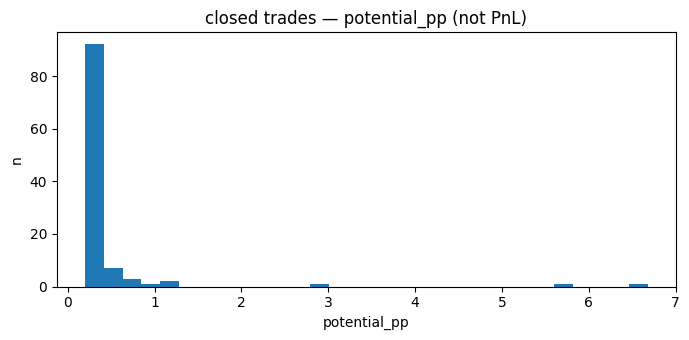

In [19]:
import matplotlib.pyplot as plt

closed_pp = (
    df_trades.loc[df_trades["status"] == "closed", "potential_pp"]
    if not df_trades.empty and "status" in df_trades.columns
    else df_trades["potential_pp"] if not df_trades.empty else None
)
if closed_pp is None or closed_pp.empty:
    print("no closed trades")
else:
    plt.figure(figsize=(7, 3.5))
    plt.hist(closed_pp.dropna(), bins=30)
    plt.xlabel("potential_pp")
    plt.ylabel("n")
    plt.title("closed trades — potential_pp (not PnL)")
    plt.tight_layout()
    plt.show()
